# Task 6: K-Nearest Neighbors (KNN) Classification

## Objective
The objective of this task is to understand and implement the K-Nearest Neighbors (KNN) algorithm for classification problems. KNN is a supervised machine learning algorithm that classifies data points based on the majority class among their nearest neighbors.

## Steps Performed
1. Loaded the Iris dataset.
2. Selected feature variables and target labels.
3. Normalized the features using StandardScaler.
4. Split the dataset into training and testing sets.
5. Trained KNN models with different values of K.
6. Evaluated model performance using Accuracy Score and Confusion Matrix.
7. Visualized the decision boundaries using two selected features.

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

## Expected Outcome
By completing this task, we learn:
- Instance-based learning
- Euclidean distance concept
- Importance of feature scaling
- K-value selection
- Classification model evaluation

Accuracy for different K values:

K = 1 --> Accuracy = 0.7333
K = 3 --> Accuracy = 0.7000
K = 5 --> Accuracy = 0.7000
K = 7 --> Accuracy = 0.7333
K = 9 --> Accuracy = 0.6667

Accuracy Score:
0.7

Confusion Matrix:
[[10  0  0]
 [ 0  6  4]
 [ 0  5  5]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.55      0.60      0.57        10
           2       0.56      0.50      0.53        10

    accuracy                           0.70        30
   macro avg       0.70      0.70      0.70        30
weighted avg       0.70      0.70      0.70        30



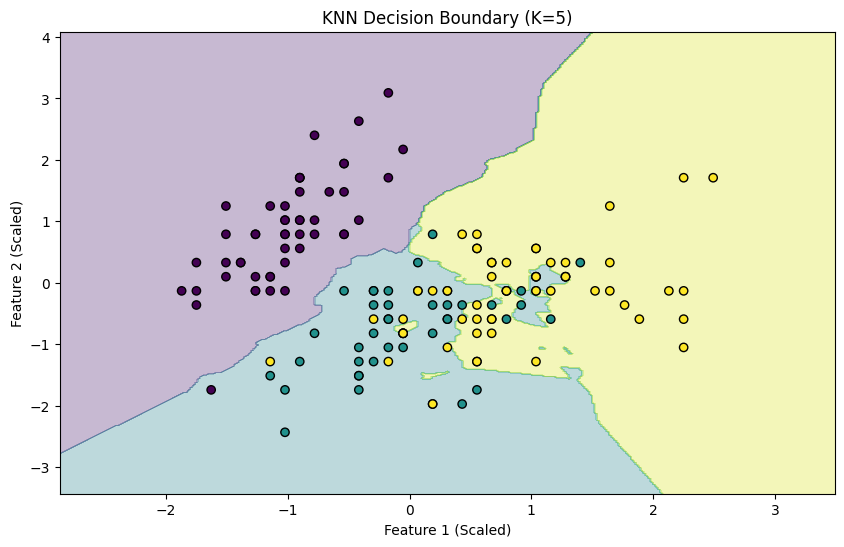

In [1]:
# Task 6: K-Nearest Neighbors (KNN) Classification

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris Dataset
iris = load_iris()

# Use only first two features for visualization
X = iris.data[:, :2]
y = iris.target

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Try different K values
k_values = [1, 3, 5, 7, 9]

print("Accuracy for different K values:\n")

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k} --> Accuracy = {acc:.4f}")

# Final Model with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# Evaluation
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Decision Boundary Visualization
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y,
    edgecolors='k'
)

plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.title("KNN Decision Boundary (K=5)")
plt.show()